In [33]:
# ============================================================
# CELDA 1: Importar librerías
# ============================================================

import mne                          # Para leer y procesar EEG
import numpy as np                  # Operaciones matemáticas vectorizadas
import pandas as pd                 # Para crear el DataFrame de resultados
import matplotlib.pyplot as plt     # Para graficar
import seaborn as sns               # Para gráficas estadísticas
from scipy import signal            # Para cálculo de PSD (Welch)
from scipy import stats             # Para pruebas estadísticas
from pathlib import Path            # Para manejar rutas de archivos

# Configuración general de gráficas
mne.set_log_level('WARNING')  # Evita que MNE imprima mensajes innecesarios
%matplotlib inline

In [34]:
# ============================================================
# CELDA 2: Rutas y parámetros globales
# ============================================================
# Ruta donde están los datos descargados
RUTA_DATOS = Path("./datos_bci/files")

# Canales de interés - grilla sensoriomotora 3x3
# Seleccionados con base en múltiples estudios de BCI basados en motor imagery:
#
# Fundamento neurofisiológico: C3, Cz y C4 están ubicados sobre las áreas
# sensoriomotoras de manos y pies. Durante motor imagery, muestran ERD sostenida
# contralateral en bandas mu y beta. La imaginación de mano izquierda produce ERD
# en C4, y la de mano derecha en C3 (ScienceDirect Topics - Motor Imagery).
#
# Dominancia contralateral: C3 produce las diferencias izquierda-derecha más
# fuertes sobre el lado contralateral, seguido de C4 (PMC7077852).
#
# Canales FC: FCz-C3 y FCz-C4 reflejan sincronía entre la corteza motora
# suplementaria (SMA) y la corteza motora primaria (M1), con dominancia
# contralateral estadísticamente significativa durante motor imagery (ResearchGate).
#
# Canales CP: complementan la cobertura de la corteza somatosensorial,
# relevante para la retroalimentación propioceptiva durante movimiento imaginado.
#
# Referencias:
#   - Lotte et al. (2010). Presence, 19(1), 54-70.
#   - Kauati-Saito et al. (2025). Sensors, 25(17), 5291.
#   - Bodda & Diwakar (2022). PLoS ONE, 17(6), e0270366.
CANALES_INTERES = [
    'Fc3.', 'Fcz.', 'Fc4.',   # Corteza motora anterior (SMA - M1)
    'C3..', 'Cz..', 'C4..',   # Corteza motora primaria (M1) - canales clave ERD/ERS
    'Cp3.', 'Cpz.', 'Cp4.'    # Corteza somatosensorial
]

# Definición de bandas de frecuencia (en Hz)
BANDAS = {
    'delta': (0.5, 4),
    'theta': (4, 8),
    'alpha': (8, 13),   # También llamada banda Mu en contexto motor
    'beta':  (13, 30),
    'gamma': (30, 40)
}

# Frecuencia de muestreo (los datos de este dataset son a 160 Hz)
FS = 160  # Hz

# Filtros
FREQ_MIN = 0.5   # Hz - límite inferior del filtro pasa banda
FREQ_MAX = 40.0  # Hz - límite superior del filtro pasa banda
FREQ_NOTCH = 60  # Hz - filtro notch (interferencia eléctrica en USA)

# Mapeo de runs a condiciones (necesario para construir el DataFrame final)
RUNS_CONDICIONES = {
    'R01': 'reposo_ojos_abiertos',
    'R02': 'reposo_ojos_cerrados',
    'R03': 'movimiento_real',
    'R04': 'imaginacion_movimiento',
    'R05': 'movimiento_real',
    'R06': 'imaginacion_movimiento',
    'R07': 'movimiento_real',
    'R08': 'imaginacion_movimiento',
    'R09': 'movimiento_real',
    'R10': 'imaginacion_movimiento',
    'R11': 'movimiento_real',
    'R12': 'imaginacion_movimiento',
    'R13': 'movimiento_real',
    'R14': 'imaginacion_movimiento',
}

# Verificación
print("Parámetros cargados correctamente")
print(f"   Ruta datos: {RUTA_DATOS}")
print(f"   Canales de interés: {CANALES_INTERES}")
print(f"   Bandas definidas: {list(BANDAS.keys())}")
print(f"   Frecuencia de muestreo: {FS} Hz")
print(f"   Filtro pasa banda: {FREQ_MIN} - {FREQ_MAX} Hz")
print(f"   Notch: {FREQ_NOTCH} Hz")

Parámetros cargados correctamente
   Ruta datos: datos_bci\files
   Canales de interés: ['Fc3.', 'Fcz.', 'Fc4.', 'C3..', 'Cz..', 'C4..', 'Cp3.', 'Cpz.', 'Cp4.']
   Bandas definidas: ['delta', 'theta', 'alpha', 'beta', 'gamma']
   Frecuencia de muestreo: 160 Hz
   Filtro pasa banda: 0.5 - 40.0 Hz
   Notch: 60 Hz


In [35]:
# ============================================================
# CELDA 2: Verificar que los datos están disponibles
# ============================================================
# Verificar que la ruta principal existe
if not RUTA_DATOS.exists():
    print("❌ ERROR: La ruta de datos no existe. Verifica RUTA_DATOS")
else:
    print(f"✅ Ruta encontrada: {RUTA_DATOS}")

# Contar sujetos disponibles
sujetos = sorted([s for s in RUTA_DATOS.iterdir() if s.is_dir()])
print(f"✅ Sujetos encontrados: {len(sujetos)}")
print(f"   Primeros 3: {[s.name for s in sujetos[:3]]}")
print(f"   Últimos 3:  {[s.name for s in sujetos[-3:]]}")

# Verificar archivos del primer sujeto
archivos_s001 = sorted((RUTA_DATOS / "S001").glob("*.edf"))
print(f"\n✅ Archivos EDF de S001: {len(archivos_s001)}")
for f in archivos_s001:
    print(f"   {f.name}")

✅ Ruta encontrada: datos_bci\files
✅ Sujetos encontrados: 109
   Primeros 3: ['S001', 'S002', 'S003']
   Últimos 3:  ['S107', 'S108', 'S109']

✅ Archivos EDF de S001: 14
   S001R01.edf
   S001R02.edf
   S001R03.edf
   S001R04.edf
   S001R05.edf
   S001R06.edf
   S001R07.edf
   S001R08.edf
   S001R09.edf
   S001R10.edf
   S001R11.edf
   S001R12.edf
   S001R13.edf
   S001R14.edf


In [36]:
# ============================================================
# CELDA 3: Función de procesamiento de señal EEG
# ============================================================
def procesar_eeg(ruta_archivo, mostrar_pasos=False):
    """
    Recibe un archivo EEG y aplica el flujo de procesamiento completo.
    
    Parámetros:
        ruta_archivo: ruta al archivo .edf
        mostrar_pasos: si True, grafica la señal en cada paso
    
    Retorna:
        raw: objeto MNE con la señal procesada
    """
    
    # --- PASO 1: Cargar el archivo ---
    # MNE puede leer archivos EDF directamente
    raw = mne.io.read_raw_edf(ruta_archivo, preload=True)
    
    if mostrar_pasos:
        print("✅ Paso 1: Archivo cargado")
        print(f"   Canales: {len(raw.ch_names)}")
        print(f"   Duración: {raw.times[-1]:.1f} segundos")
        print(f"   Frecuencia de muestreo: {raw.info['sfreq']} Hz")
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        # Señal en tiempo (primeros 5 canales para no saturar)
        data, times = raw[:5, :int(FS*5)]
        for i, canal in enumerate(raw.ch_names[:5]):
            axes[0].plot(times, data[i] * 1e6, label=canal)
        axes[0].set_title("PASO 1: Señal cruda (dominio tiempo)")
        axes[0].set_xlabel("Tiempo (s)")
        axes[0].set_ylabel("Amplitud (µV)")
        axes[0].legend(loc='upper right', fontsize=8)
        axes[0].grid(True)
        # Espectro de frecuencias
        raw.compute_psd(fmax=80).plot(axes=axes[1], show=False)
        axes[1].set_title("PASO 1: Espectro crudo")
        axes[1].grid(True)
        plt.tight_layout()
        plt.show()
    
    # --- PASO 2: Seleccionar canales de interés ---
    # Solo trabajamos con la grilla sensoriomotora 3x3 para reducir carga computacional
    canales_disponibles = [c for c in CANALES_INTERES if c in raw.ch_names]
    raw.pick(canales_disponibles)
    
    if mostrar_pasos:
        print(f"\n✅ Paso 2: Canales seleccionados: {canales_disponibles}")
    
    # --- PASO 3: Filtro pasa banda (0.5 - 40 Hz) ---
    # Elimina deriva de baja frecuencia y ruido de alta frecuencia
    raw.filter(l_freq=FREQ_MIN, h_freq=FREQ_MAX, method='fir')
    
    if mostrar_pasos:
        print(f"\n✅ Paso 3: Filtro pasa banda aplicado ({FREQ_MIN}-{FREQ_MAX} Hz)")
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        # Señal en tiempo (todos los 9 canales seleccionados)
        data, times = raw[:, :int(FS*5)]
        for i, canal in enumerate(raw.ch_names):
            axes[0].plot(times, data[i] * 1e6, label=canal)
        axes[0].set_title("PASO 3: Después del filtro pasa banda (dominio tiempo)")
        axes[0].set_xlabel("Tiempo (s)")
        axes[0].set_ylabel("Amplitud (µV)")
        axes[0].legend(loc='upper right', fontsize=7)
        axes[0].grid(True)
        # Espectro - se ve claramente el corte en 40 Hz
        raw.compute_psd(fmax=80).plot(axes=axes[1], show=False)
        axes[1].set_title("PASO 3: Espectro después del filtro pasa banda")
        axes[1].grid(True)
        plt.tight_layout()
        plt.show()
    
    # --- PASO 4: Filtro Notch (60 Hz) ---
    # Elimina la interferencia de la red eléctrica
    # Nota: con FREQ_MAX=40Hz el notch es casi redundante, pero se aplica
    # como buena práctica del pipeline estándar en BCI
    raw.notch_filter(freqs=FREQ_NOTCH)
    
    if mostrar_pasos:
        print(f"\n✅ Paso 4: Filtro Notch aplicado ({FREQ_NOTCH} Hz)")
        fig, axes = plt.subplots(1, 2, figsize=(14, 4))
        # Señal en tiempo
        data, times = raw[:, :int(FS*5)]
        for i, canal in enumerate(raw.ch_names):
            axes[0].plot(times, data[i] * 1e6, label=canal)
        axes[0].set_title("PASO 4: Después del filtro Notch (dominio tiempo)")
        axes[0].set_xlabel("Tiempo (s)")
        axes[0].set_ylabel("Amplitud (µV)")
        axes[0].legend(loc='upper right', fontsize=7)
        axes[0].grid(True)
        # Espectro
        raw.compute_psd(fmax=80).plot(axes=axes[1], show=False)
        axes[1].set_title("PASO 4: Espectro después del filtro Notch")
        axes[1].grid(True)
        plt.tight_layout()
        plt.show()
    
    return raw

# Verificación
print("✅ Función procesar_eeg() definida correctamente")

✅ Función procesar_eeg() definida correctamente


In [37]:
# ============================================================
# CELDA 3: Exploración de datos antes de procesar
# ============================================================
# Cargamos un archivo de prueba para explorar su contenido
archivo_prueba = RUTA_DATOS / "S001" / "S001R03.edf"
raw_explorar = mne.io.read_raw_edf(archivo_prueba, preload=False)

# Ver información general
print("=== INFORMACIÓN GENERAL ===")
print(f"Canales totales: {len(raw_explorar.ch_names)}")
print(f"Duración: {raw_explorar.times[-1]:.1f} segundos")
print(f"Frecuencia de muestreo: {raw_explorar.info['sfreq']} Hz")
print(f"Muestras totales: {len(raw_explorar.times)}")

# Ver anotaciones/eventos del archivo
print("\n=== ANOTACIONES (EVENTOS) ===")
print(raw_explorar.annotations)

=== INFORMACIÓN GENERAL ===
Canales totales: 64
Duración: 125.0 segundos
Frecuencia de muestreo: 160.0 Hz
Muestras totales: 20000

=== ANOTACIONES (EVENTOS) ===
<Annotations | 30 segments: T0 (15), T1 (8), T2 (7)>


✅ Paso 1: Archivo cargado
   Canales: 64
   Duración: 125.0 segundos
   Frecuencia de muestreo: 160.0 Hz


C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_44840\506583328.py:36: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=80).plot(axes=axes[1], show=False)


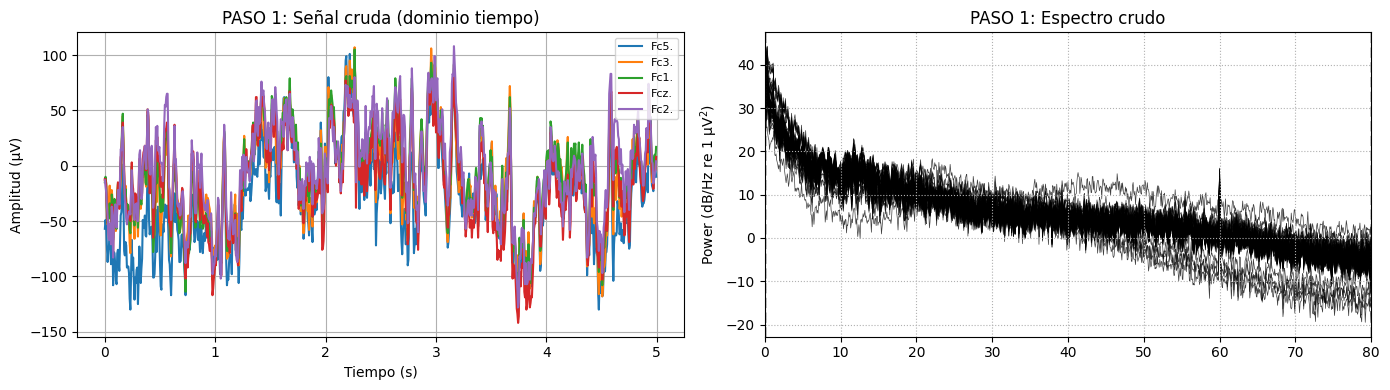


✅ Paso 2: Canales seleccionados: ['Fc3.', 'Fcz.', 'Fc4.', 'C3..', 'Cz..', 'C4..', 'Cp3.', 'Cpz.', 'Cp4.']

✅ Paso 3: Filtro pasa banda aplicado (0.5-40.0 Hz)


C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_44840\506583328.py:67: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=80).plot(axes=axes[1], show=False)


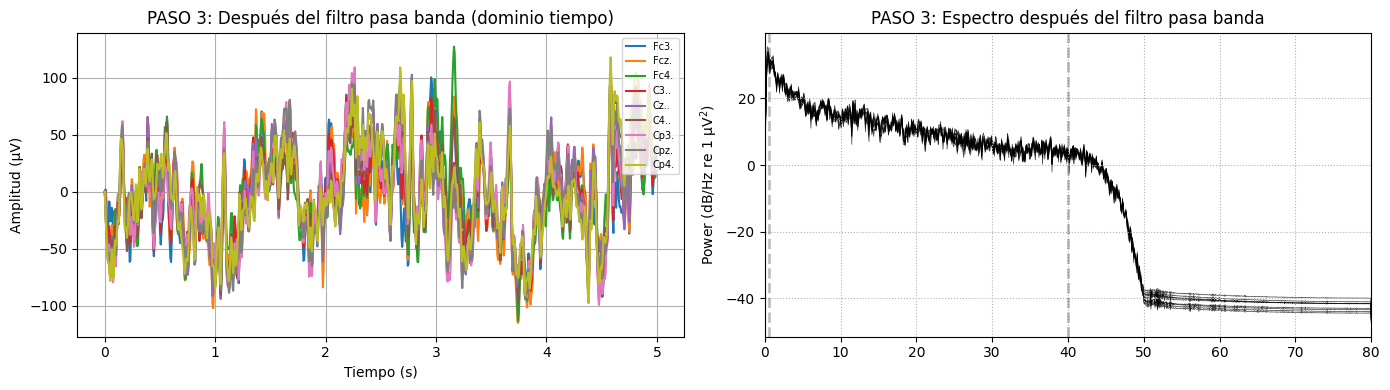


✅ Paso 4: Filtro Notch aplicado (60 Hz)


C:\Users\Valentina Garcia\AppData\Local\Temp\ipykernel_44840\506583328.py:92: RuntimeWarning: Channel locations not available. Disabling spatial colors.
  raw.compute_psd(fmax=80).plot(axes=axes[1], show=False)


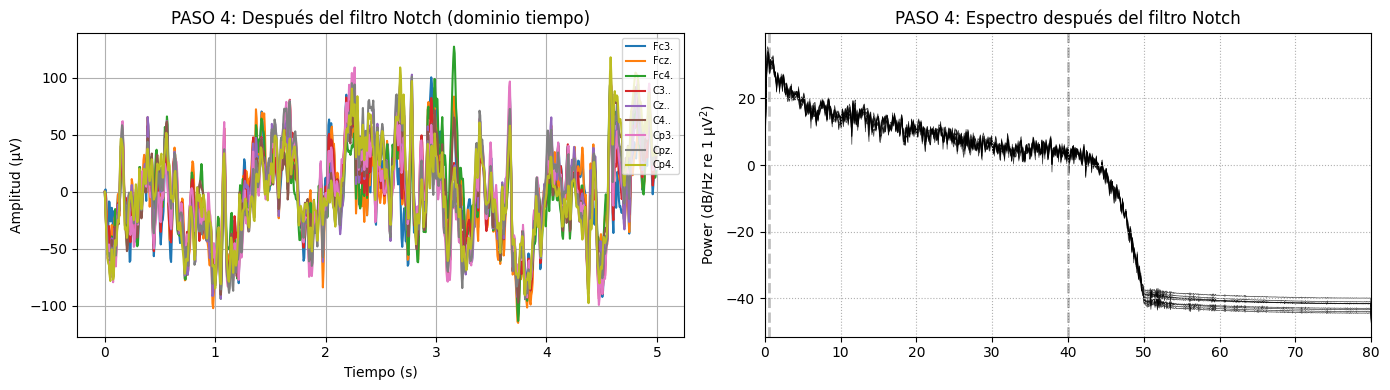

In [38]:
# ============================================================
# CELDA 3: Prueba de la función de procesamiento (para el informe)
# ============================================================
# Usamos un run de movimiento real para la prueba visual
archivo_prueba = RUTA_DATOS / "S001" / "S001R03.edf"

# Ejecutamos con mostrar_pasos=True para ver los cambios en cada fase
raw_prueba = procesar_eeg(archivo_prueba, mostrar_pasos=True)

In [39]:
# ============================================================
# CELDA 7: Explorar anotaciones y segmentos
# ============================================================
# Cargamos un archivo procesado para ver cómo vienen los segmentos
archivo_prueba = RUTA_DATOS / "S001" / "S001R03.edf"
raw_test = procesar_eeg(archivo_prueba, mostrar_pasos=False)

# Ver las anotaciones disponibles
print("=== ANOTACIONES DEL ARCHIVO S001R03 ===")
for ann in raw_test.annotations:
    print(f"   Etiqueta: {ann['description']} | Inicio: {ann['onset']:.1f}s | Duración: {ann['duration']:.1f}s")

# Ver cuántos segmentos hay de cada tipo
etiquetas = [ann['description'] for ann in raw_test.annotations]
print(f"\n=== RESUMEN ===")
print(f"   T0 (reposo):       {etiquetas.count('T0')} segmentos")
print(f"   T1 (mano izq):     {etiquetas.count('T1')} segmentos")
print(f"   T2 (mano der):     {etiquetas.count('T2')} segmentos")
print(f"   Duración típica:   {raw_test.annotations[0]['duration']:.1f} segundos")

=== ANOTACIONES DEL ARCHIVO S001R03 ===
   Etiqueta: T0 | Inicio: 0.0s | Duración: 4.2s
   Etiqueta: T2 | Inicio: 4.2s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 8.3s | Duración: 4.2s
   Etiqueta: T1 | Inicio: 12.5s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 16.6s | Duración: 4.2s
   Etiqueta: T1 | Inicio: 20.8s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 24.9s | Duración: 4.2s
   Etiqueta: T2 | Inicio: 29.1s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 33.2s | Duración: 4.2s
   Etiqueta: T2 | Inicio: 37.4s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 41.5s | Duración: 4.2s
   Etiqueta: T1 | Inicio: 45.7s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 49.8s | Duración: 4.2s
   Etiqueta: T1 | Inicio: 54.0s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 58.1s | Duración: 4.2s
   Etiqueta: T2 | Inicio: 62.3s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 66.4s | Duración: 4.2s
   Etiqueta: T1 | Inicio: 70.6s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 74.7s | Duración: 4.2s
   Etiqueta: T2 | Inicio: 78.9s 

In [40]:
# ============================================================
# CELDA 4: Función para calcular PSD por bandas
# ============================================================
def calcular_psd_por_bandas(raw):
    """
    Calcula la densidad espectral de potencia (PSD) para cada
    canal y cada banda de frecuencia definida en BANDAS.
    
    Parámetros:
        raw: objeto MNE con la señal ya procesada
    
    Retorna:
        resultado: diccionario con potencia promedio por banda y canal
                   Ejemplo: {'alpha_C3..': 0.23, 'beta_C4..': 0.15, ...}
    """
    
    # Extraer los datos como array de numpy
    # datos tiene forma: (n_canales, n_muestras)
    datos = raw.get_data()
    fs = raw.info['sfreq']  # ⚠️ link roto corregido
    
    resultado = {}  # aquí guardamos la potencia de cada banda y canal
    
    # Iterar sobre cada canal
    for idx, canal in enumerate(raw.ch_names):  # ⚠️ link roto corregido
        
        señal_canal = datos[idx, :]  # señal de este canal
        
        # Calcular PSD usando el método de Welch
        # - nperseg: tamaño de cada segmento (2 segundos de datos)
        # - Por qué Welch? Promedia varios segmentos, reduce el ruido
        freqs, psd = signal.welch(
            señal_canal,
            fs=fs,
            nperseg=int(fs * 2)  # ventana de 2 segundos
        )
        
        # Para cada banda, extraer la potencia promedio
        for nombre_banda, (f_min, f_max) in BANDAS.items():
            
            # Encontrar índices de frecuencias dentro de la banda
            # Ejemplo: para alpha (8-13 Hz), buscar todos los índices
            # donde freqs está entre 8 y 13
            indices_banda = np.where(
                (freqs >= f_min) & (freqs <= f_max)
            )[0]
            
            # Potencia promedio en esa banda = promedio de la PSD
            # en las frecuencias de interés
            potencia = np.mean(psd[indices_banda])
            
            # Guardar con clave "banda_canal", ejemplo: "alpha_C3.."
            clave = f"{nombre_banda}_{canal}"
            resultado[clave] = potencia
    
    return resultado

# Verificación
print("Función calcular_psd_por_bandas() definida correctamente")

Función calcular_psd_por_bandas() definida correctamente


In [ ]:
# ===================================================cd Proyecto_1=========
# CELDA 4b: Prueba de la función calcular_psd_por_bandas
# ============================================================
# Usamos el archivo ya procesado anteriormente
archivo_prueba = RUTA_DATOS / "S001" / "S001R03.edf"
raw_test = procesar_eeg(archivo_prueba, mostrar_pasos=False)

# Calcular PSD
resultado_prueba = calcular_psd_por_bandas(raw_test)

# Mostrar resultados
print("=== RESULTADO PSD POR BANDAS Y CANAL ===")
for clave, potencia in resultado_prueba.items():
    print(f"   {clave}: {potencia:.2e} V²/Hz")

# Verificar que tenemos todas las combinaciones
n_esperado = len(BANDAS) * len(CANALES_INTERES)
print(f"\n=== VERIFICACIÓN ===")
print(f"   Combinaciones esperadas (bandas x canales): {n_esperado}")
print(f"   Combinaciones obtenidas: {len(resultado_prueba)}")

=== RESULTADO PSD POR BANDAS Y CANAL ===
   delta_Fc3.: 4.56e-10 V²/Hz
   theta_Fc3.: 7.76e-11 V²/Hz
   alpha_Fc3.: 3.78e-11 V²/Hz
   beta_Fc3.: 1.32e-11 V²/Hz
   gamma_Fc3.: 2.99e-12 V²/Hz
   delta_Fcz.: 4.35e-10 V²/Hz
   theta_Fcz.: 8.80e-11 V²/Hz
   alpha_Fcz.: 3.74e-11 V²/Hz
   beta_Fcz.: 1.29e-11 V²/Hz
   gamma_Fcz.: 3.15e-12 V²/Hz
   delta_Fc4.: 3.54e-10 V²/Hz
   theta_Fc4.: 6.14e-11 V²/Hz
   alpha_Fc4.: 2.93e-11 V²/Hz
   beta_Fc4.: 1.02e-11 V²/Hz
   gamma_Fc4.: 2.50e-12 V²/Hz
   delta_C3..: 3.80e-10 V²/Hz
   theta_C3..: 7.41e-11 V²/Hz
   alpha_C3..: 3.89e-11 V²/Hz
   beta_C3..: 1.21e-11 V²/Hz
   gamma_C3..: 3.04e-12 V²/Hz
   delta_Cz..: 3.84e-10 V²/Hz
   theta_Cz..: 8.21e-11 V²/Hz
   alpha_Cz..: 3.78e-11 V²/Hz
   beta_Cz..: 1.17e-11 V²/Hz
   gamma_Cz..: 3.30e-12 V²/Hz
   delta_C4..: 2.93e-10 V²/Hz
   theta_C4..: 5.60e-11 V²/Hz
   alpha_C4..: 2.91e-11 V²/Hz
   beta_C4..: 9.52e-12 V²/Hz
   gamma_C4..: 2.54e-12 V²/Hz
   delta_Cp3.: 3.69e-10 V²/Hz
   theta_Cp3.: 7.30e-11 V²/Hz
   al

In [42]:
# ============================================================
# CELDA 4c: Verificación visual de la PSD por bandas
# ============================================================
# Organizar resultados por banda para comparar canales
print("=== POTENCIA POR BANDA (en µV²/Hz) ===\n")

for banda in BANDAS.keys():
    print(f"--- {banda.upper()} ---")
    for canal in CANALES_INTERES:
        clave = f"{banda}_{canal}"
        # Convertir de V²/Hz a µV²/Hz (multiplicar por 1e12)
        potencia_uv = resultado_prueba[clave] * 1e12
        print(f"   {canal}: {potencia_uv:.4f} µV²/Hz")
    print()

=== POTENCIA POR BANDA (en µV²/Hz) ===

--- DELTA ---
   Fc3.: 456.2533 µV²/Hz
   Fcz.: 434.7547 µV²/Hz
   Fc4.: 354.4238 µV²/Hz
   C3..: 379.6878 µV²/Hz
   Cz..: 383.9974 µV²/Hz
   C4..: 293.0944 µV²/Hz
   Cp3.: 368.9739 µV²/Hz
   Cpz.: 387.1058 µV²/Hz
   Cp4.: 320.3040 µV²/Hz

--- THETA ---
   Fc3.: 77.5603 µV²/Hz
   Fcz.: 88.0078 µV²/Hz
   Fc4.: 61.4017 µV²/Hz
   C3..: 74.0846 µV²/Hz
   Cz..: 82.1415 µV²/Hz
   C4..: 56.0042 µV²/Hz
   Cp3.: 72.9780 µV²/Hz
   Cpz.: 74.2424 µV²/Hz
   Cp4.: 59.4481 µV²/Hz

--- ALPHA ---
   Fc3.: 37.7941 µV²/Hz
   Fcz.: 37.4326 µV²/Hz
   Fc4.: 29.3452 µV²/Hz
   C3..: 38.9486 µV²/Hz
   Cz..: 37.7547 µV²/Hz
   C4..: 29.1187 µV²/Hz
   Cp3.: 42.4917 µV²/Hz
   Cpz.: 40.7007 µV²/Hz
   Cp4.: 35.0045 µV²/Hz

--- BETA ---
   Fc3.: 13.1562 µV²/Hz
   Fcz.: 12.8672 µV²/Hz
   Fc4.: 10.2322 µV²/Hz
   C3..: 12.0870 µV²/Hz
   Cz..: 11.6753 µV²/Hz
   C4..: 9.5175 µV²/Hz
   Cp3.: 11.9294 µV²/Hz
   Cpz.: 11.4764 µV²/Hz
   Cp4.: 10.3746 µV²/Hz

--- GAMMA ---
   Fc3.: 2.9869

In [44]:
# ============================================================
# CELDA 5: Explorar anotaciones y segmentos
# ============================================================
# Cargamos un archivo procesado para ver cómo vienen los segmentos
archivo_prueba = RUTA_DATOS / "S001" / "S001R03.edf"
raw_test = procesar_eeg(archivo_prueba, mostrar_pasos=False)

# Ver las anotaciones disponibles
print("=== ANOTACIONES DEL ARCHIVO S001R03 ===")
for ann in raw_test.annotations:
    print(f"   Etiqueta: {ann['description']} | Inicio: {ann['onset']:.1f}s | Duración: {ann['duration']:.1f}s")

# Ver cuántos segmentos hay de cada tipo
etiquetas = [ann['description'] for ann in raw_test.annotations]
print(f"\n=== RESUMEN ===")
print(f"   T0 (reposo):       {etiquetas.count('T0')} segmentos")
print(f"   T1 (mano izq):     {etiquetas.count('T1')} segmentos")
print(f"   T2 (mano der):     {etiquetas.count('T2')} segmentos")
print(f"   Duración típica:   {raw_test.annotations[0]['duration']:.1f} segundos")

=== ANOTACIONES DEL ARCHIVO S001R03 ===
   Etiqueta: T0 | Inicio: 0.0s | Duración: 4.2s
   Etiqueta: T2 | Inicio: 4.2s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 8.3s | Duración: 4.2s
   Etiqueta: T1 | Inicio: 12.5s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 16.6s | Duración: 4.2s
   Etiqueta: T1 | Inicio: 20.8s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 24.9s | Duración: 4.2s
   Etiqueta: T2 | Inicio: 29.1s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 33.2s | Duración: 4.2s
   Etiqueta: T2 | Inicio: 37.4s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 41.5s | Duración: 4.2s
   Etiqueta: T1 | Inicio: 45.7s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 49.8s | Duración: 4.2s
   Etiqueta: T1 | Inicio: 54.0s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 58.1s | Duración: 4.2s
   Etiqueta: T2 | Inicio: 62.3s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 66.4s | Duración: 4.2s
   Etiqueta: T1 | Inicio: 70.6s | Duración: 4.1s
   Etiqueta: T0 | Inicio: 74.7s | Duración: 4.2s
   Etiqueta: T2 | Inicio: 78.9s 

In [45]:
# ============================================================
# CELDA 6: Función para identificar condición del archivo
# ============================================================
import re

def identificar_condicion(nombre_archivo):
    """
    Dado el nombre de un archivo, retorna la condición experimental.
    
    Parámetros:
        nombre_archivo: string con el nombre del archivo
                        Ejemplo: "S001R03.edf"
    
    Retorna:
        condicion: string con la condición
    """
    
    nombre = str(nombre_archivo)
    
    # Extraer número de run del nombre del archivo
    # Busca el patrón "RXX" en el nombre, ejemplo: S001R03.edf → run 3
    match = re.search(r'R(\d+)', nombre)
    
    if match is None:
        return "desconocido"
    
    run = int(match.group(1))
    
    # Mapear run a condición
    if run in [1, 2]:
        return "reposo"
    elif run in [3, 7, 11]:
        return "movimiento_manos"
    elif run in [4, 8, 12]:
        return "imaginacion_manos"
    elif run in [5, 9, 13]:
        return "movimiento_punos"
    elif run in [6, 10, 14]:
        return "imaginacion_punos"
    else:
        return "desconocido"

# Verificación
print("✅ Función identificar_condicion() definida correctamente")
print("\n=== PRUEBA ===")
for archivo in ["S001R01.edf", "S001R03.edf", "S001R04.edf", "S001R05.edf", "S001R06.edf"]:
    print(f"   {archivo} → {identificar_condicion(archivo)}")

✅ Función identificar_condicion() definida correctamente

=== PRUEBA ===
   S001R01.edf → reposo
   S001R03.edf → movimiento_manos
   S001R04.edf → imaginacion_manos
   S001R05.edf → movimiento_punos
   S001R06.edf → imaginacion_punos


In [46]:
# ============================================================
# CELDA 7: Función para calcular PSD por segmentos (T0, T1, T2)
# ============================================================
def calcular_psd_por_segmentos(raw):
    """
    Extrae los segmentos T0, T1, T2 del archivo y calcula
    la PSD promedio para cada tipo de segmento.
    
    Parámetros:
        raw: objeto MNE con la señal ya procesada
    
    Retorna:
        resultado: diccionario con potencia promedio por 
                   etiqueta, banda y canal
                   Ejemplo: {'T0_alpha_C3..': 0.23, 
                              'T1_beta_C4..': 0.15, ...}
    """
    
    fs = raw.info['sfreq']
    resultado = {}
    
    # Agrupar segmentos por etiqueta (T0, T1, T2)
    segmentos_por_etiqueta = {'T0': [], 'T1': [], 'T2': []}
    
    for ann in raw.annotations:
        etiqueta = ann['description']
        if etiqueta not in segmentos_por_etiqueta:
            continue
        
        # Extraer inicio y fin del segmento en muestras
        inicio = int(ann['onset'] * fs)
        fin = inicio + int(ann['duration'] * fs)
        
        # Extraer datos del segmento (todos los canales)
        # datos tiene forma: (n_canales, n_muestras_segmento)
        datos_segmento = raw.get_data()[:, inicio:fin]
        segmentos_por_etiqueta[etiqueta].append(datos_segmento)
    
    # Para cada etiqueta calcular PSD promedio
    for etiqueta, segmentos in segmentos_por_etiqueta.items():
        
        if len(segmentos) == 0:
            continue
        
        # Calcular PSD para cada segmento y promediar
        for idx, canal in enumerate(raw.ch_names):
            
            psds_canal = []  # PSD de cada segmento para este canal
            
            for segmento in segmentos:
                señal = segmento[idx, :]
                freqs, psd = signal.welch(
                    señal,
                    fs=fs,
                    nperseg=int(fs * 2)  # ventana de 2 segundos
                )
                psds_canal.append(psd)
            
            # Promedio de todas las PSDs del mismo tipo
            psd_promedio = np.mean(psds_canal, axis=0)
            
            # Extraer potencia por banda
            for nombre_banda, (f_min, f_max) in BANDAS.items():
                indices_banda = np.where(
                    (freqs >= f_min) & (freqs <= f_max)
                )[0]
                potencia = np.mean(psd_promedio[indices_banda])
                
                # Clave: "T0_alpha_C3.."
                clave = f"{etiqueta}_{nombre_banda}_{canal}"
                resultado[clave] = potencia
    
    return resultado

# Verificación
print("✅ Función calcular_psd_por_segmentos() definida correctamente")

✅ Función calcular_psd_por_segmentos() definida correctamente


In [47]:
# ============================================================
# CELDA 7b: Prueba de calcular_psd_por_segmentos
# ============================================================
# Usamos el mismo archivo de prueba
archivo_prueba = RUTA_DATOS / "S001" / "S001R03.edf"
raw_test = procesar_eeg(archivo_prueba, mostrar_pasos=False)

# Calcular PSD por segmentos
resultado_segmentos = calcular_psd_por_segmentos(raw_test)

# Mostrar resultados organizados por etiqueta y banda
print("=== PSD POR SEGMENTOS (en µV²/Hz) ===\n")
for etiqueta in ['T0', 'T1', 'T2']:
    print(f"--- {etiqueta} ---")
    for banda in BANDAS.keys():
        for canal in ['C3..', 'Cz..', 'C4..']:  # solo C3, Cz, C4 para no saturar
            clave = f"{etiqueta}_{banda}_{canal}"
            if clave in resultado_segmentos:
                potencia_uv = resultado_segmentos[clave] * 1e12
                print(f"   {banda}_{canal}: {potencia_uv:.4f} µV²/Hz")
    print()

# Verificación
n_esperado = len(['T0','T1','T2']) * len(BANDAS) * len(CANALES_INTERES)
print(f"=== VERIFICACIÓN ===")
print(f"   Combinaciones esperadas (etiquetas x bandas x canales): {n_esperado}")
print(f"   Combinaciones obtenidas: {len(resultado_segmentos)}")

=== PSD POR SEGMENTOS (en µV²/Hz) ===

--- T0 ---
   delta_C3..: 319.5002 µV²/Hz
   delta_Cz..: 353.4208 µV²/Hz
   delta_C4..: 249.4330 µV²/Hz
   theta_C3..: 66.0405 µV²/Hz
   theta_Cz..: 74.8227 µV²/Hz
   theta_C4..: 53.2134 µV²/Hz
   alpha_C3..: 39.9974 µV²/Hz
   alpha_Cz..: 38.0680 µV²/Hz
   alpha_C4..: 32.2472 µV²/Hz
   beta_C3..: 12.2339 µV²/Hz
   beta_Cz..: 11.4479 µV²/Hz
   beta_C4..: 10.3455 µV²/Hz
   gamma_C3..: 2.9654 µV²/Hz
   gamma_Cz..: 3.1124 µV²/Hz
   gamma_C4..: 2.6697 µV²/Hz

--- T1 ---
   delta_C3..: 411.7781 µV²/Hz
   delta_Cz..: 385.9264 µV²/Hz
   delta_C4..: 296.4670 µV²/Hz
   theta_C3..: 74.4361 µV²/Hz
   theta_Cz..: 69.8934 µV²/Hz
   theta_C4..: 47.6130 µV²/Hz
   alpha_C3..: 35.7002 µV²/Hz
   alpha_Cz..: 35.0893 µV²/Hz
   alpha_C4..: 24.4312 µV²/Hz
   beta_C3..: 10.7814 µV²/Hz
   beta_Cz..: 11.1253 µV²/Hz
   beta_C4..: 8.1261 µV²/Hz
   gamma_C3..: 2.8138 µV²/Hz
   gamma_Cz..: 3.4188 µV²/Hz
   gamma_C4..: 2.4448 µV²/Hz

--- T2 ---
   delta_C3..: 240.0623 µV²/Hz
  